# Mapping Potential Visual Exposure Along Street Segments

**Study area:** Bryant Park and surrounding Midtown blocks, Manhattan  
**Method:** Bivariate spatial classification  
**Unit of analysis:** Street segment

## Research Question

**How do proximity to trees and buildings shape the potential visual exposure of street segments?**

## Project Goal

This project investigates how proximity to building edges and street trees shapes potential visual-exposure conditions along street segments around Bryant Park. It extends the course methods of nearest-neighbor analysis, spatial joins, and bivariate mapping by applying both variables to a shared street-segment unit. The project aims to identify relative conditions of observation, screening, and openness rather than measure actual surveillance or visibility.

## Analytical Framing

This project uses two spatial proxies:

- **Building proximity** represents proximity to potential observation from façades, windows, entrances, and occupied building edges.
- **Tree proximity** represents potential visual screening from nearby street vegetation.

The analysis does **not** directly prove that a person is being watched or hidden. It maps spatial conditions that may increase or reduce potential visual exposure.

## 01 — Methodological precedent

1. Prepare two variables independently.
2. Attach both variables to the same spatial unit.
3. Divide each variable into two relative classes.
4. Combine the two classes into four spatial conditions.
5. Visualize the combined result on a map.

Here, the two variables are:

- distance to the nearest mapped street tree;
- distance to the nearest building footprint.

## 02 — Project Workflow

![Project workflow](figures/final-project-workflow.png)

The workflow aligns three public spatial datasets to one analytical unit. Every street segment is sampled at its midpoint; nearest-tree and nearest-building-edge distances are then joined back to the original segment. Median thresholds convert each continuous variable into relative Near/Far classes, which are combined into four potential visual-exposure conditions.

## 03 — Import libraries

The notebook uses GeoPandas for spatial analysis, Shapely for geometry, Matplotlib for static maps, and Requests for downloading public data.

In [1]:
from pathlib import Path
from urllib.parse import urlencode
import json
import warnings

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import requests
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from shapely.geometry import box, LineString
from shapely.ops import nearest_points

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Cellular-tissue palette adapted from the supplied reference image.
# The page background remains white; map layers use saturated blue-green,
# leaf green, coral, and mustard accents.
WHITE = "#FFFFFF"
CREAM = "#F3F6E9"
INK = "#103D45"          # deep teal for text and outlines
DEEP_TEAL = "#135A68"    # primary structural line color
TEAL = "#1C7782"
CYAN = "#3A9FA8"
LIGHT_CYAN = "#B9DCD5"
PALE_GREEN = "#DDE9D2"   # quiet building fill
LEAF_GREEN = "#3E8755"   # vegetation / low exposure
OLIVE = "#789847"
MUSTARD = "#C2A53D"      # open condition / midpoint accent
CORAL = "#E36A50"        # high exposure
DARK_CORAL = "#A94740"
BLUE = "#245F9C"         # screened condition

TREE_DISTANCE_CMAP = LinearSegmentedColormap.from_list(
    "tree_distance_cellular",
    [DEEP_TEAL, LEAF_GREEN, OLIVE, MUSTARD, CREAM]
)

BUILDING_DISTANCE_CMAP = LinearSegmentedColormap.from_list(
    "building_distance_cellular",
    [DARK_CORAL, CORAL, MUSTARD, CYAN, CREAM]
)


# Dark atmospheric palette for the final presentation map.
HERO_BG = "#0D1517"
HERO_BG_2 = "#142124"
HERO_BUILDING_FILL = "#203034"
HERO_BUILDING_EDGE = "#365055"
HERO_STREET_BASE = "#36565D"
HERO_TREE_GLOW = "#8CD36A"
HERO_TREE_CORE = "#D3F29B"
HERO_TREE_LINK = "#7DD494"
HERO_BUILDING_LINK = "#E58A72"
HERO_TEXT = "#EFF5EE"
HERO_MUTED_TEXT = "#AFC2BE"

EXPOSURE_COLORS = {
    "High Visual Exposure": CORAL,
    "Screened Exposure": BLUE,
    "Low Visual Exposure": LEAF_GREEN,
    "Open Exposure": MUSTARD,
}

plt.rcParams.update({
    "figure.facecolor": WHITE,
    "axes.facecolor": WHITE,
    "savefig.facecolor": WHITE,
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.edgecolor": DEEP_TEAL,
    "font.size": 11,
})

print("GeoPandas:", gpd.__version__)
print("Cellular-tissue palette loaded.")

GeoPandas: 1.1.3
Cellular-tissue palette loaded.


## 04 — Define the Bryant Park study area

The bounding box includes Bryant Park and nearby Midtown streets between approximately Fifth and Sixth Avenues and West 39th to West 44th Streets.

Coordinates are stored in WGS84 (`EPSG:4326`) for downloading and then reprojected to New York State Plane (`EPSG:2263`) for distance calculations.

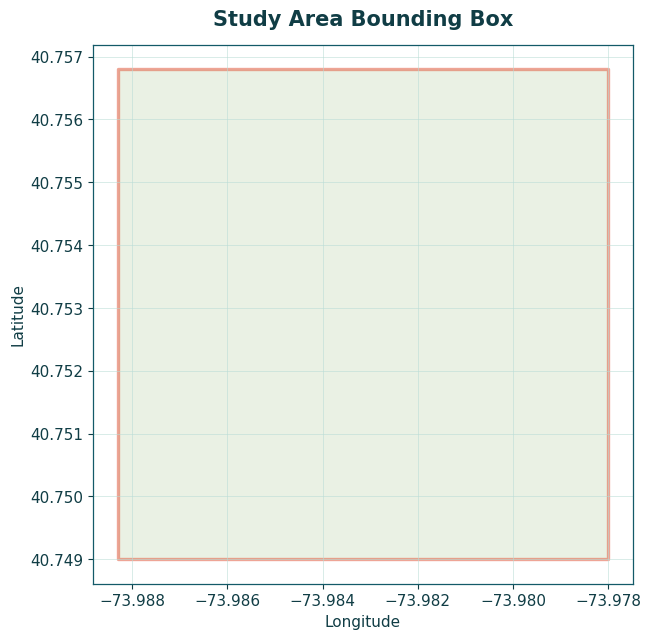

In [2]:
# WGS84 bounding box: west, south, east, north
WEST, SOUTH, EAST, NORTH = -73.9883, 40.7490, -73.9780, 40.7568

study_area = gpd.GeoDataFrame(
    {"name": ["Bryant Park and surrounding Midtown blocks"]},
    geometry=[box(WEST, SOUTH, EAST, NORTH)],
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(7, 7), facecolor=WHITE)
study_area.plot(
    ax=ax,
    facecolor=PALE_GREEN,
    edgecolor=CORAL,
    linewidth=2.4,
    alpha=0.60
)
ax.set_title("Study Area Bounding Box", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(color=LIGHT_CYAN, linewidth=0.7, alpha=0.55)
for spine in ax.spines.values():
    spine.set_color(DEEP_TEAL)
    spine.set_linewidth(0.9)
plt.show()

## 05 — Download or load public spatial data

The notebook uses three public datasets:

1. **NYC Street Centerline (CSCL)** — street-segment geometry.
2. **2015 Street Tree Census** — mapped street-tree points.
3. **NYC Building Footprints** — building polygons.

In [3]:
DATASETS = {
    "streets": {
        "id": "inkn-q76z",
        "local": DATA_DIR / "streets.geojson",
        "source": "NYC Street Centerline (CSCL)"
    },
    "trees": {
        "id": "uvpi-gqnh",
        "local": DATA_DIR / "trees.geojson",
        "source": "2015 Street Tree Census"
    },
    "buildings": {
        "id": "5zhs-2jue",
        "local": DATA_DIR / "buildings.geojson",
        "source": "NYC Building Footprints"
    }
}

BASE_RESOURCE = "https://data.cityofnewyork.us/resource"

# Use one requests session that ignores broken local proxy settings.
SESSION = requests.Session()
SESSION.trust_env = False


def download_socrata_geojson(dataset_id, output_path, bbox, limit=50000):
    """Download a spatial subset from a Socrata GeoJSON endpoint."""
    west, south, east, north = bbox
    geometry_fields = ["the_geom", "geometry"]
    errors = []

    for geom_field in geometry_fields:
        where = f"within_box({geom_field}, {north}, {west}, {south}, {east})"
        params = {"$limit": limit, "$where": where}
        url = f"{BASE_RESOURCE}/{dataset_id}.geojson"
        try:
            response = SESSION.get(url, params=params, timeout=120)
            response.raise_for_status()
            payload = response.json()
            if payload.get("type") == "FeatureCollection":
                output_path.write_text(json.dumps(payload), encoding="utf-8")
                print(
                    f"Downloaded {len(payload.get('features', [])):,} features → {output_path}"
                )
                return gpd.read_file(output_path)
        except Exception as exc:
            errors.append(f"{geom_field}: {exc}")

    raise RuntimeError(
        "The automatic NYC Open Data request failed. Download the dataset "
        f"manually and save it as {output_path}. Attempts: " + " | ".join(errors)
    )


def download_tree_points(output_path, bbox, limit=50000):
    """Download tree records by latitude/longitude and create point geometry.

    The Street Tree Census endpoint does not support the same geometry-field
    filter used by the street and building datasets, so it is handled separately.
    """
    west, south, east, north = bbox
    url = f"{BASE_RESOURCE}/uvpi-gqnh.json"
    params = {
        "$limit": limit,
        "$where": (
            f"latitude >= {south} AND latitude <= {north} "
            f"AND longitude >= {west} AND longitude <= {east}"
        )
    }

    response = SESSION.get(url, params=params, timeout=120)
    response.raise_for_status()
    records = response.json()

    if not records:
        raise RuntimeError(
            "The tree request succeeded but returned no records for the study area."
        )

    valid_records = [
        row for row in records
        if row.get("longitude") not in (None, "")
        and row.get("latitude") not in (None, "")
    ]

    if not valid_records:
        raise RuntimeError("Tree records were returned, but none contained coordinates.")

    trees = gpd.GeoDataFrame(
        valid_records,
        geometry=gpd.points_from_xy(
            [float(row["longitude"]) for row in valid_records],
            [float(row["latitude"]) for row in valid_records]
        ),
        crs="EPSG:4326"
    )

    trees.to_file(output_path, driver="GeoJSON")
    print(f"Downloaded {len(trees):,} tree points → {output_path}")
    return trees


def load_or_download(name):
    info = DATASETS[name]
    path = info["local"]

    if path.exists():
        print(f"Loading local {name}: {path}")
        return gpd.read_file(path)

    print(f"Requesting {info['source']} from NYC Open Data...")

    if name == "trees":
        return download_tree_points(
            path, (WEST, SOUTH, EAST, NORTH)
        )

    return download_socrata_geojson(
        info["id"], path, (WEST, SOUTH, EAST, NORTH)
    )


# Run this cell with internet access, or place the three local files in data/.
streets_raw = load_or_download("streets")
trees_raw = load_or_download("trees")
buildings_raw = load_or_download("buildings")

print("Street features:", len(streets_raw))
print("Tree features:", len(trees_raw))
print("Building features:", len(buildings_raw))


Requesting NYC Street Centerline (CSCL) from NYC Open Data...
Downloaded 112 features → data/streets.geojson
Requesting 2015 Street Tree Census from NYC Open Data...
Downloaded 308 tree points → data/trees.geojson
Requesting NYC Building Footprints from NYC Open Data...
Downloaded 519 features → data/buildings.geojson
Street features: 112
Tree features: 308
Building features: 519


### Inspect the raw datasets

This step checks geometry types, coordinate reference systems, and available attributes before analysis.

In [4]:
for name, layer in {
    "streets": streets_raw,
    "trees": trees_raw,
    "buildings": buildings_raw
}.items():
    print("\n", name.upper())
    print("CRS:", layer.crs)
    print("Geometry types:", layer.geometry.geom_type.value_counts().to_dict())
    display(layer.head(3))


 STREETS
CRS: EPSG:4326
Geometry types: {'MultiLineString': 112}


,stname_label,rw_type,segment_type_value,l_low_hn,sandist_ind,bphys_id,pre_directional,rsubsect,number_park_lanes,avgtravtime,borough_indicator,created_date,r_zip,r_low_hn,bike_lane,nominaldir,post_type,rwjurisdiction,joinid,nonped,l_blockfaceid,pre_type,post_directional,collectionmethod,fire_lane,objectid,globalid,segment_type,street_name,within_bndy_dist,truck_route_type,b5sc,full_street_name,shape_length,streetwidth_irr,status,posted_speed,carto_display_level,r_high_hn,l_zip,segmentlength,streetwidth,lsubsect,special_disaster,r_blockfaceid,fcc,boroughcode,to_level_code,post_modifier,pre_modifier,bike_trafdir,continuous_parity_flag,trafdir,number_total_lanes,twisted_parity_flag,snow_priority,modified_date,number_travel_lanes,physicalid,from_level_code,accessible,l_high_hn,seglocstatus,geometry
0,MADISON AVE,1,None,218,NaN,None,NaN,2B,2,None,None,2007-11-29 00:00:00+00:00,10016,217,NaN,None,AVE,None,None,None,1222602891,NaN,None,NaN,None,2966,d1caeadb-8e57-4b4e-8bc3-ea6fbdd00d81,None,MADISON,None,NaN,125390,MADISON AVE,103.88628357719818,None,2,25,NaN,231,10016,257.8118176,46,2B,None,1222603206,None,1,13,None,None,NaN,None,FT,4,N,C,2024-03-20 10:13:45+00:00,2,3574,13,None,230,NaN,"MULTILINESTRING ((-73.98203 40.74906, -73.9815..."
1,E 41 ST,1,None,NaN,NaN,None,E,2B,0,None,None,2007-11-29 00:00:00+00:00,10017,NaN,NaN,None,ST,None,None,None,1222600141,NaN,None,NaN,None,74323,37938ee2-985a-467f-8cf1-cf0059b72e1b,None,41,None,NaN,117810,E 41 ST,15.786034899676753,None,2,25,NaN,NaN,10017,39.90062503,35,2B,None,1222600105,None,1,13,None,None,NaN,None,FT,2,N,S,2017-03-17 09:47:30+00:00,2,82147,13,None,NaN,NaN,"MULTILINESTRING ((-73.97828 40.75151, -73.9781..."
2,E 37 ST,1,None,1,NaN,None,E,2B,2,None,None,2007-11-29 00:00:00+00:00,10016,2,NaN,None,ST,None,None,None,1222602401,NaN,None,NaN,None,20944,53ea9339-cf02-4302-8bd7-fd6fe19ec2a8,None,37,None,NaN,117730,E 37 ST,203.94665283267943,None,2,25,NaN,18,10016,507.15978393,35,2B,None,1222602890,None,1,13,None,None,NaN,None,TF,4,N,S,2017-03-17 09:59:31+00:00,2,23428,13,None,17,NaN,"MULTILINESTRING ((-73.98318 40.75035, -73.9815..."



 TREES
CRS: EPSG:4326
Geometry types: {'Point': 308}


,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,steward,guards,sidewalk,user_type,problems,root_stone,root_grate,root_other,trunk_wire,trnk_light,trnk_other,brch_light,brch_shoe,brch_other,address,zipcode,zip_city,cb_num,borocode,boroname,cncldist,st_assem,st_senate,nta,nta_name,boro_ct,state,latitude,longitude,x_sp,y_sp,council_district,census_tract,bin,bbl,geometry
0,187229,104671,2015-08-29T00:00:00.000,4,0,OnCurb,Alive,Fair,Gleditsia triacanthos var. inermis,honeylocust,3or4,Helpful,NoDamage,NYC Parks Staff,"RootOther,TrunkOther,BranchOther",No,No,Yes,No,No,Yes,No,No,Yes,301 MADISON AVENUE,10017,New York,105,1,Manhattan,4,73,27,MN20,Murray Hill-Kips Bay,1008200,New York,40.75235028,-73.97971637,989869.8454,213378.8197,4,82,1035331,1012760022,POINT (-73.97972 40.75235)
1,187230,104671,2015-08-29T00:00:00.000,4,0,OnCurb,Alive,Fair,Gleditsia triacanthos var. inermis,honeylocust,3or4,Helpful,NoDamage,NYC Parks Staff,"RootOther,TrunkOther,BranchOther",No,No,Yes,No,No,Yes,No,No,Yes,301 MADISON AVENUE,10017,New York,105,1,Manhattan,4,73,27,MN20,Murray Hill-Kips Bay,1008200,New York,40.75230061,-73.97975264,989859.7998,213360.7206,4,82,1035331,1012760022,POINT (-73.97975 40.7523)
2,192356,104731,2015-08-31T00:00:00.000,8,0,OnCurb,Alive,Good,Pyrus calleryana,Callery pear,None,None,Damage,Volunteer,"MetalGrates,BranchOther",No,Yes,No,No,No,No,No,No,Yes,1411 BROADWAY,10018,New York,105,1,Manhattan,3,75,27,MN17,Midtown-Midtown South,1011300,New York,40.7541827,-73.98702476,987844.8616,214046.0451,3,113,1015275,1008150001,POINT (-73.98702 40.75418)



 BUILDINGS
CRS: EPSG:4326
Geometry types: {'MultiPolygon': 519}


,name,base_bbl,shape_area,construction_year,ground_elevation,mappluto_bbl,objectid,feature_code,shape_length,height_roof,last_status_type,bin,last_edited_date,geom_source,doitt_id,geometry
0,NaN,1012600071,1210.6484375,1911,62,1012600071,835387,2100,146.22993696803528,112.35,Constructed,1034240,2017-08-22 19:05:16+00:00,Photogrammetric,276586,"MULTIPOLYGON (((-73.98225 40.75643, -73.98232 ..."
1,NaN,1012610112,355.07421875,1920,62,1012610112,835337,2100,97.584120486741455,76.49,Constructed,1034267,2017-08-22 17:28:51+00:00,Photogrammetric,369932,"MULTIPOLYGON (((-73.98134 40.7566, -73.98151 4..."
2,NaN,1009960046,1402.09375,1905,57,1009960046,998259,2100,152.36477874412455,78.58,Constructed,1022617,2018-08-31 15:16:35+00:00,Photogrammetric,394337,"MULTIPOLYGON (((-73.98437 40.75657, -73.98454 ..."


## 06 — Prepare and align the data

Distance calculations require a projected coordinate system. All layers are converted to `EPSG:2263`, whose units are US survey feet.

The notebook then clips each layer to the study area and removes empty or invalid geometries.

In [5]:
TARGET_CRS = "EPSG:2263"
study_area_projected = study_area.to_crs(TARGET_CRS)


def clean_and_clip(layer, study_polygon):
    if layer.crs is None:
        raise ValueError("A source layer has no CRS. Assign its original CRS before continuing.")
    layer = layer.to_crs(TARGET_CRS).copy()
    layer = layer[layer.geometry.notna() & ~layer.geometry.is_empty].copy()
    layer["geometry"] = layer.geometry.make_valid()
    return gpd.clip(layer, study_polygon)

streets = clean_and_clip(streets_raw, study_area_projected)
trees = clean_and_clip(trees_raw, study_area_projected)
buildings = clean_and_clip(buildings_raw, study_area_projected)

# Keep the correct dominant geometry type for each layer.
streets = streets[streets.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()
trees = trees[trees.geometry.geom_type == "Point"].copy()
buildings = buildings[buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

print(f"Prepared streets: {len(streets):,}")
print(f"Prepared trees: {len(trees):,}")
print(f"Prepared buildings: {len(buildings):,}")

Prepared streets: 112
Prepared trees: 308
Prepared buildings: 519


### Map the prepared input layers

This map verifies that streets, trees, and buildings overlap correctly before any measurements are made.

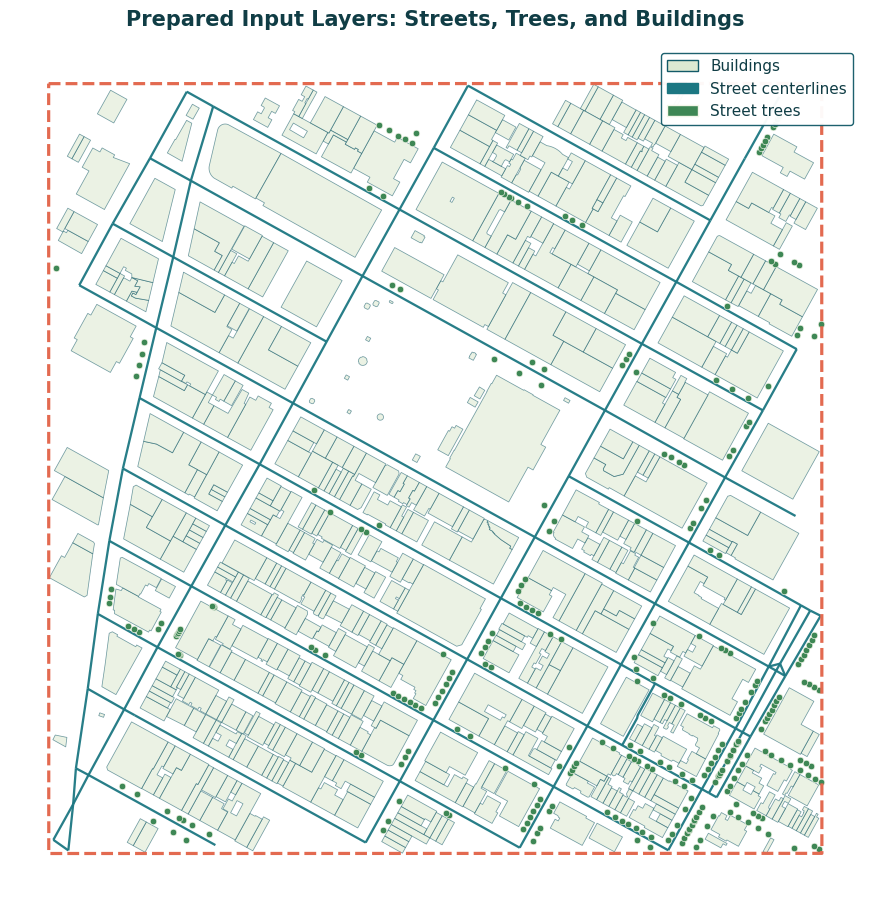

In [6]:
fig, ax = plt.subplots(figsize=(11, 11), facecolor=WHITE)

# Pale green urban blocks, teal street network, and saturated green trees.
buildings.plot(
    ax=ax,
    facecolor=PALE_GREEN,
    edgecolor=DEEP_TEAL,
    linewidth=0.55,
    alpha=0.58,
    zorder=1
)
streets.plot(
    ax=ax,
    color=TEAL,
    linewidth=1.65,
    alpha=0.95,
    zorder=2
)
trees.plot(
    ax=ax,
    color=LEAF_GREEN,
    edgecolor=CREAM,
    linewidth=0.45,
    markersize=22,
    zorder=3
)
study_area_projected.boundary.plot(
    ax=ax,
    color=CORAL,
    linewidth=2.3,
    linestyle="--",
    zorder=4
)

legend_handles = [
    Patch(facecolor=PALE_GREEN, edgecolor=DEEP_TEAL, label="Buildings"),
    Patch(facecolor=TEAL, edgecolor=TEAL, label="Street centerlines"),
    Patch(facecolor=LEAF_GREEN, edgecolor=CREAM, label="Street trees"),
]
ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    facecolor=WHITE,
    edgecolor=DEEP_TEAL,
    framealpha=0.96
)
ax.set_title("Prepared Input Layers: Streets, Trees, and Buildings", fontsize=15, fontweight="bold", pad=14)
ax.set_axis_off()
plt.show()

## 07 — Define the unit of analysis

Each row in the street-centerline data is treated as an individual street segment. A midpoint is generated along the length of every segment and used as a consistent sampling location.

The midpoint is a measuring device; the final result is joined back to the full street line.

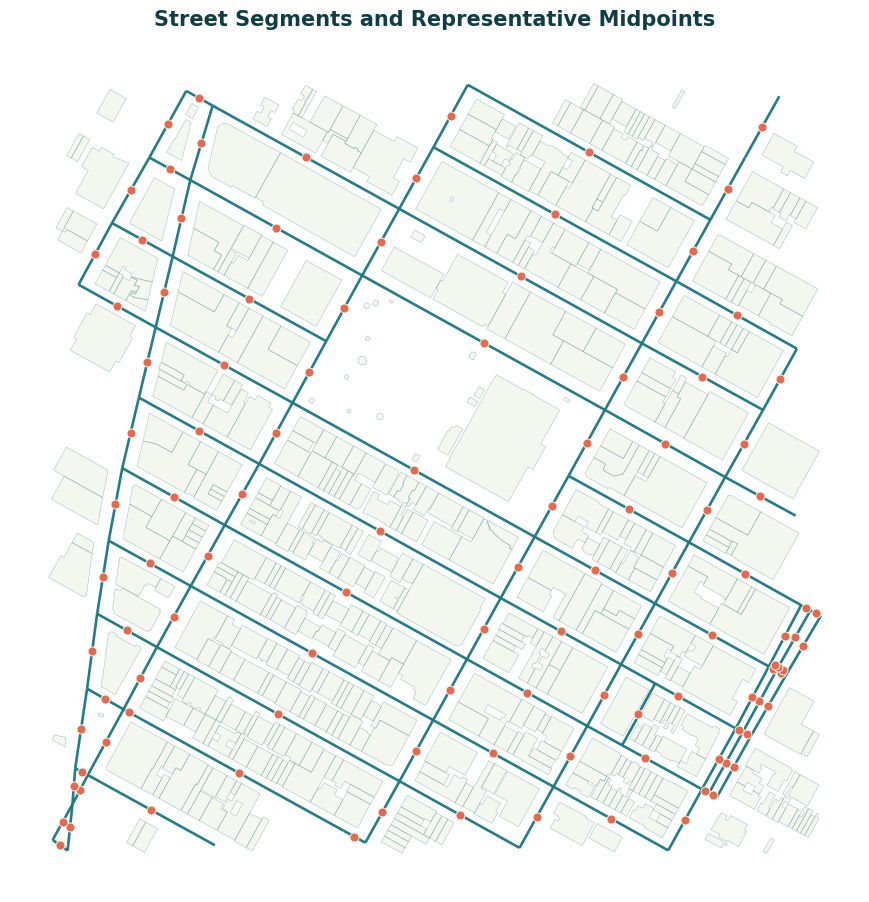

,segment_id,geometry
0,SEG_0001,POINT (987536.364 212188.684)
1,SEG_0002,POINT (987572.934 212254.38)
2,SEG_0003,POINT (987545.291 212273.899)
3,SEG_0004,POINT (987872.679 212318.195)
4,SEG_0005,POINT (987610.187 212393.565)


In [7]:
streets = streets.explode(index_parts=False).reset_index(drop=True)
streets["segment_id"] = [f"SEG_{i:04d}" for i in range(1, len(streets) + 1)]

street_midpoints = streets[["segment_id", "geometry"]].copy()
street_midpoints["geometry"] = streets.geometry.interpolate(0.5, normalized=True)

fig, ax = plt.subplots(figsize=(11, 11), facecolor=WHITE)
buildings.plot(
    ax=ax,
    facecolor=PALE_GREEN,
    edgecolor=DEEP_TEAL,
    linewidth=0.4,
    alpha=0.34,
    zorder=1
)
streets.plot(
    ax=ax,
    color=TEAL,
    linewidth=1.9,
    alpha=0.96,
    zorder=2
)
street_midpoints.plot(
    ax=ax,
    color=CORAL,
    edgecolor=CREAM,
    linewidth=0.7,
    markersize=42,
    zorder=3
)
ax.set_title("Street Segments and Representative Midpoints", fontsize=15, fontweight="bold", pad=14)
ax.set_axis_off()
plt.show()

street_midpoints.head()

## 08 — Variable 1: distance to the nearest tree

For every street midpoint, the nearest mapped street tree is identified with `sjoin_nearest`.

Interpretation used in this project:

- shorter tree distance → stronger potential visual screening;
- longer tree distance → weaker potential visual screening.

In [8]:
tree_join = gpd.sjoin_nearest(
    street_midpoints,
    trees[["geometry"]],
    how="left",
    distance_col="tree_distance_ft"
)

# A tie can create duplicate midpoint rows. Keep the minimum distance per segment.
tree_distances = (
    tree_join.groupby("segment_id", as_index=False)["tree_distance_ft"].min()
)

tree_distances["tree_distance_m"] = tree_distances["tree_distance_ft"] * 0.3048006096

tree_distances.describe()

,tree_distance_ft,tree_distance_m
count,112.000000,112.000000
mean,155.353747,47.351917
std,146.273570,44.584273
min,6.512526,1.985022
25%,40.427156,12.322222
50%,112.756162,34.368147
75%,242.229604,73.831731
max,670.095097,204.245394


### Tree-distance map

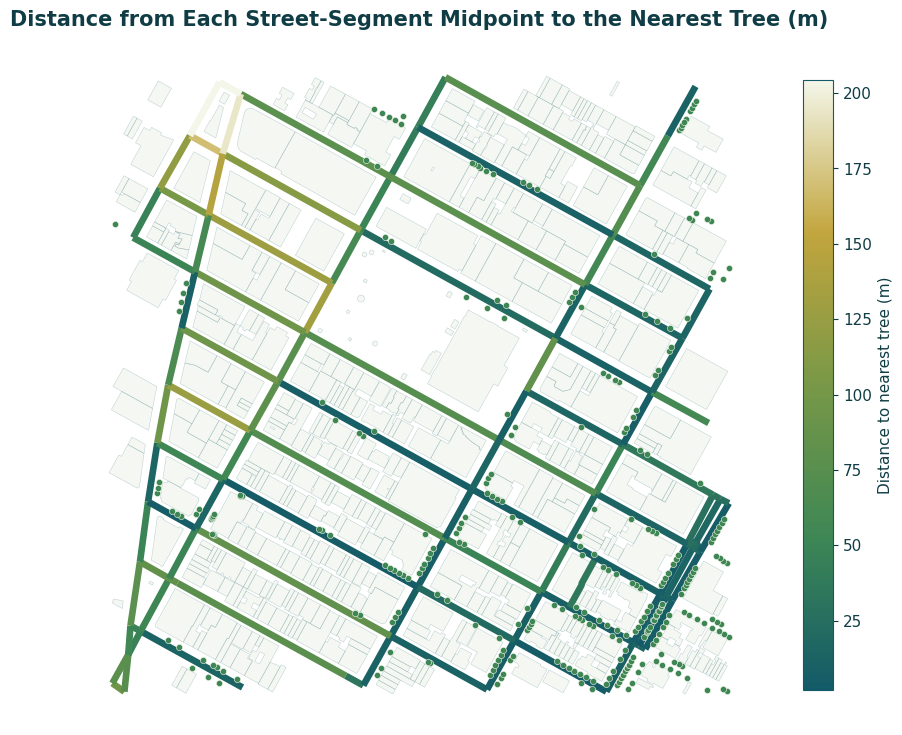

In [9]:
tree_map = streets.merge(tree_distances, on="segment_id", how="left")

fig, ax = plt.subplots(figsize=(11, 11), facecolor=WHITE)
buildings.plot(
    ax=ax,
    facecolor=PALE_GREEN,
    edgecolor=DEEP_TEAL,
    linewidth=0.35,
    alpha=0.28,
    zorder=1
)
tree_map.plot(
    ax=ax,
    column="tree_distance_m",
    cmap=TREE_DISTANCE_CMAP,
    legend=True,
    linewidth=4.8,
    zorder=2,
    missing_kwds={"color": LIGHT_CYAN, "label": "No tree match"},
    legend_kwds={"label": "Distance to nearest tree (m)", "shrink": 0.72}
)
trees.plot(
    ax=ax,
    color=LEAF_GREEN,
    edgecolor=CREAM,
    linewidth=0.4,
    markersize=20,
    zorder=3
)
ax.set_title("Distance from Each Street-Segment Midpoint to the Nearest Tree (m)", fontsize=15, fontweight="bold", pad=14)
ax.set_axis_off()
plt.show()

## 09 — Variable 2: distance to the nearest building edge

For every street midpoint, the nearest building footprint is identified.

Interpretation used in this project:

- shorter building distance → closer to potential observation from occupied building edges;
- longer building distance → farther from those potential observation interfaces.

In [10]:
building_join = gpd.sjoin_nearest(
    street_midpoints,
    buildings[["geometry"]],
    how="left",
    distance_col="building_distance_ft"
)

building_distances = (
    building_join.groupby("segment_id", as_index=False)["building_distance_ft"].min()
)

building_distances["building_distance_m"] = (
    building_distances["building_distance_ft"] * 0.3048006096
)

building_distances.describe()

,building_distance_ft,building_distance_m
count,112.000000,112.000000
mean,51.890492,15.816254
std,36.094420,11.001601
min,8.694789,2.650177
25%,31.479315,9.594914
50%,47.895547,14.598592
75%,51.735728,15.769081
max,247.693832,75.497231


### Building-distance map

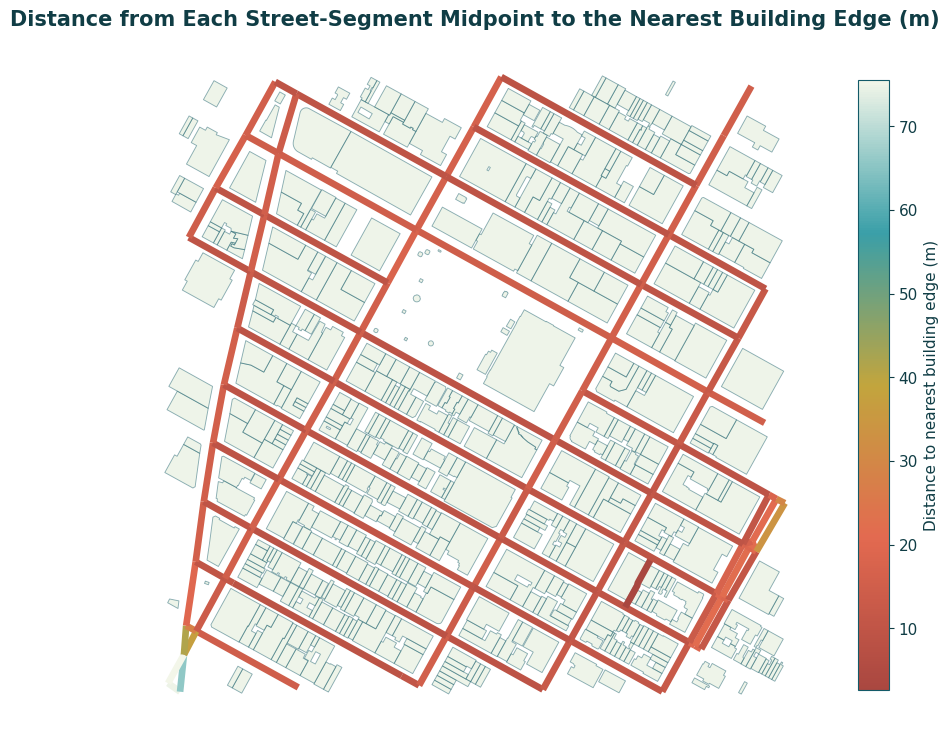

In [11]:
building_map = streets.merge(building_distances, on="segment_id", how="left")

fig, ax = plt.subplots(figsize=(11, 11), facecolor=WHITE)
buildings.plot(
    ax=ax,
    facecolor=PALE_GREEN,
    edgecolor=DEEP_TEAL,
    linewidth=0.65,
    alpha=0.48,
    zorder=1
)
building_map.plot(
    ax=ax,
    column="building_distance_m",
    cmap=BUILDING_DISTANCE_CMAP,
    legend=True,
    linewidth=4.8,
    zorder=2,
    missing_kwds={"color": LIGHT_CYAN, "label": "No building match"},
    legend_kwds={"label": "Distance to nearest building edge (m)", "shrink": 0.72}
)
ax.set_title("Distance from Each Street-Segment Midpoint to the Nearest Building Edge (m)", fontsize=15, fontweight="bold", pad=14)
ax.set_axis_off()
plt.show()

## 10 — Merge the two variables

The tree and building measurements are attached to the same street-segment geometry. This produces the central analytical dataset for the project.

In [12]:
street_results = (
    streets
    .merge(tree_distances, on="segment_id", how="left")
    .merge(building_distances, on="segment_id", how="left")
)

analysis_columns = [
    "segment_id",
    "tree_distance_m",
    "building_distance_m",
    "geometry"
]
street_results[analysis_columns].head()

,segment_id,tree_distance_m,building_distance_m,geometry
0,SEG_0001,95.722500,74.741218,"LINESTRING (987564.007 212169.165, 987508.721 ..."
1,SEG_0002,74.116365,65.740022,"LINESTRING (987564.007 212169.165, 987581.861 ..."
2,SEG_0003,77.615183,75.497231,"LINESTRING (987508.721 212208.203, 987581.861 ..."
3,SEG_0004,12.551026,14.860461,"LINESTRING (988106.846 212188.853, 987638.513 ..."
4,SEG_0005,46.685494,37.325364,"LINESTRING (987581.861 212339.594, 987638.513 ..."


## 11 — Classify each variable as Near or Far

Following a bivariate mapping method, each continuous distance is divided into two relative classes using the study-area median.

This does not claim that the median is a universal perceptual threshold. It is a transparent way to compare segments **within this study area**.

In [13]:
tree_threshold = street_results["tree_distance_m"].median()
building_threshold = street_results["building_distance_m"].median()

street_results["tree_class"] = street_results["tree_distance_m"].apply(
    lambda value: "Tree Near" if value <= tree_threshold else "Tree Far"
)

street_results["building_class"] = street_results["building_distance_m"].apply(
    lambda value: "Building Near" if value <= building_threshold else "Building Far"
)

print(f"Tree median threshold: {tree_threshold:.2f} m")
print(f"Building median threshold: {building_threshold:.2f} m")

street_results[[
    "segment_id", "tree_distance_m", "tree_class",
    "building_distance_m", "building_class"
]].head()

Tree median threshold: 34.37 m
Building median threshold: 14.60 m


,segment_id,tree_distance_m,tree_class,building_distance_m,building_class
0,SEG_0001,95.722500,Tree Far,74.741218,Building Far
1,SEG_0002,74.116365,Tree Far,65.740022,Building Far
2,SEG_0003,77.615183,Tree Far,75.497231,Building Far
3,SEG_0004,12.551026,Tree Near,14.860461,Building Far
4,SEG_0005,46.685494,Tree Far,37.325364,Building Far


## 12 — Create four potential visual-exposure conditions

| Building condition | Tree condition | Final class | Interpretation |
|---|---|---|---|
| Near | Far | **High Visual Exposure** | Potential observation is close; vegetation screening is distant. |
| Far | Near | **Low Visual Exposure** | Potential observation is distant; vegetation screening is close. |
| Near | Near | **Screened Exposure** | Observation and screening conditions coexist. |
| Far | Far | **Open Exposure** | Both occupied building edges and vegetation screening are relatively distant. |

These categories are analytical proxies, not direct measurements of actual visibility.

In [14]:
def classify_exposure(row):
    building_near = row["building_class"] == "Building Near"
    tree_near = row["tree_class"] == "Tree Near"

    if building_near and not tree_near:
        return "High Visual Exposure"
    if not building_near and tree_near:
        return "Low Visual Exposure"
    if building_near and tree_near:
        return "Screened Exposure"
    return "Open Exposure"

street_results["exposure_condition"] = street_results.apply(
    classify_exposure, axis=1
)

street_results["exposure_condition"].value_counts()

exposure_condition
Open Exposure           30
Screened Exposure       30
Low Visual Exposure     26
High Visual Exposure    26
Name: count, dtype: int64

### Analysis Summary

This cell reports the key values that should be visible in the submitted notebook: the number of street segments, both median thresholds, and the distribution of the four final classes.

In [15]:
analysis_summary = pd.DataFrame({
    "metric": [
        "Street segments",
        "Median distance to nearest tree (m)",
        "Median distance to nearest building edge (m)",
        "Most common exposure condition",
        "Least common exposure condition",
    ],
    "value": [
        f"{len(street_results):,}",
        f"{tree_threshold:.2f}",
        f"{building_threshold:.2f}",
        street_results["exposure_condition"].value_counts().idxmax(),
        street_results["exposure_condition"].value_counts().idxmin(),
    ],
})

display(analysis_summary)

condition_percentages = (
    street_results["exposure_condition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .rename("percentage")
    .to_frame()
)
display(condition_percentages)

,metric,value
0,Street segments,112
1,Median distance to nearest tree (m),34.37
2,Median distance to nearest building edge (m),14.60
3,Most common exposure condition,Open Exposure
4,Least common exposure condition,Low Visual Exposure


,percentage
exposure_condition,
Open Exposure,26.8
Screened Exposure,26.8
Low Visual Exposure,23.2
High Visual Exposure,23.2


## 13 — Final bivariate street map

This is the main result: every street segment is classified using the combined relationship between tree proximity and building proximity.

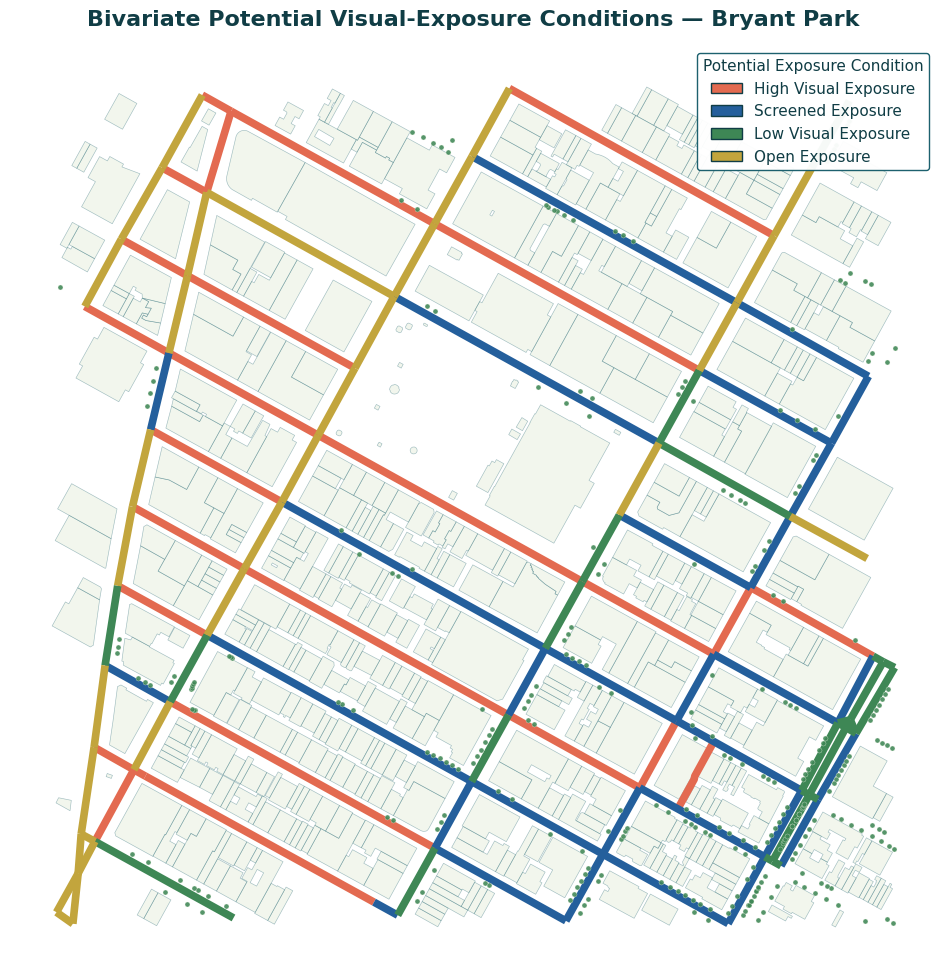

In [16]:
category_order = [
    "High Visual Exposure",
    "Screened Exposure",
    "Low Visual Exposure",
    "Open Exposure"
]
street_results["exposure_condition"] = pd.Categorical(
    street_results["exposure_condition"],
    categories=category_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(12, 12), facecolor=WHITE)

# Quiet cellular base layer so the four street conditions remain dominant.
buildings.plot(
    ax=ax,
    facecolor=PALE_GREEN,
    edgecolor=DEEP_TEAL,
    linewidth=0.45,
    alpha=0.38,
    zorder=1
)

for condition in category_order:
    subset = street_results[street_results["exposure_condition"] == condition]
    subset.plot(
        ax=ax,
        color=EXPOSURE_COLORS[condition],
        linewidth=5.5,
        zorder=3
    )

trees.plot(
    ax=ax,
    color=LEAF_GREEN,
    edgecolor=CREAM,
    linewidth=0.25,
    markersize=13,
    alpha=0.88,
    zorder=4
)

legend_handles = [
    Patch(facecolor=EXPOSURE_COLORS[c], edgecolor=INK, label=c)
    for c in category_order
]
ax.legend(
    handles=legend_handles,
    title="Potential Exposure Condition",
    loc="upper right",
    frameon=True,
    facecolor=WHITE,
    edgecolor=DEEP_TEAL,
    framealpha=0.96
)
ax.set_title("Bivariate Potential Visual-Exposure Conditions — Bryant Park", fontsize=16, fontweight="bold", pad=14)
ax.set_axis_off()
plt.show()

## 14 — Final atmospheric presentation map

The clean bivariate map above remains the primary analytical result. This second map translates the same data into a layered presentation figure inspired by dark, networked cartography.

It adds two explicit spatial relationships:

- green lines connect each street-segment midpoint to its nearest mapped tree;
- coral lines connect each midpoint to the nearest point on a building footprint.

The colored street network still represents the four bivariate exposure conditions. The relationship lines reveal how those classifications were produced rather than functioning as decorative flows.


In [17]:
# Build explicit relational geometries for the final presentation map.
# When several targets are tied at the same distance, keep the first match.

tree_match_rows = (
    tree_join
    .sort_values(["segment_id", "tree_distance_ft"])
    .drop_duplicates("segment_id")
    .copy()
)

building_match_rows = (
    building_join
    .sort_values(["segment_id", "building_distance_ft"])
    .drop_duplicates("segment_id")
    .copy()
)


def build_tree_links(matches, target_layer):
    records = []
    for _, row in matches.iterrows():
        target_index = row.get("index_right")
        if pd.isna(target_index):
            continue

        midpoint = row.geometry
        tree_point = target_layer.loc[target_index, "geometry"]

        records.append({
            "segment_id": row["segment_id"],
            "distance_m": float(row["tree_distance_ft"]) * 0.3048006096,
            "geometry": LineString([midpoint, tree_point])
        })

    return gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs=street_midpoints.crs
    )


def build_building_links(matches, target_layer):
    records = []
    for _, row in matches.iterrows():
        target_index = row.get("index_right")
        if pd.isna(target_index):
            continue

        midpoint = row.geometry
        building_geometry = target_layer.loc[target_index, "geometry"]
        midpoint_on_line, nearest_building_point = nearest_points(
            midpoint,
            building_geometry
        )

        records.append({
            "segment_id": row["segment_id"],
            "distance_m": float(row["building_distance_ft"]) * 0.3048006096,
            "geometry": LineString([
                midpoint_on_line,
                nearest_building_point
            ])
        })

    return gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs=street_midpoints.crs
    )


tree_links = build_tree_links(tree_match_rows, trees)
building_links = build_building_links(building_match_rows, buildings)

print(f"Tree relationship lines: {len(tree_links):,}")
print(f"Building relationship lines: {len(building_links):,}")


Tree relationship lines: 112
Building relationship lines: 112


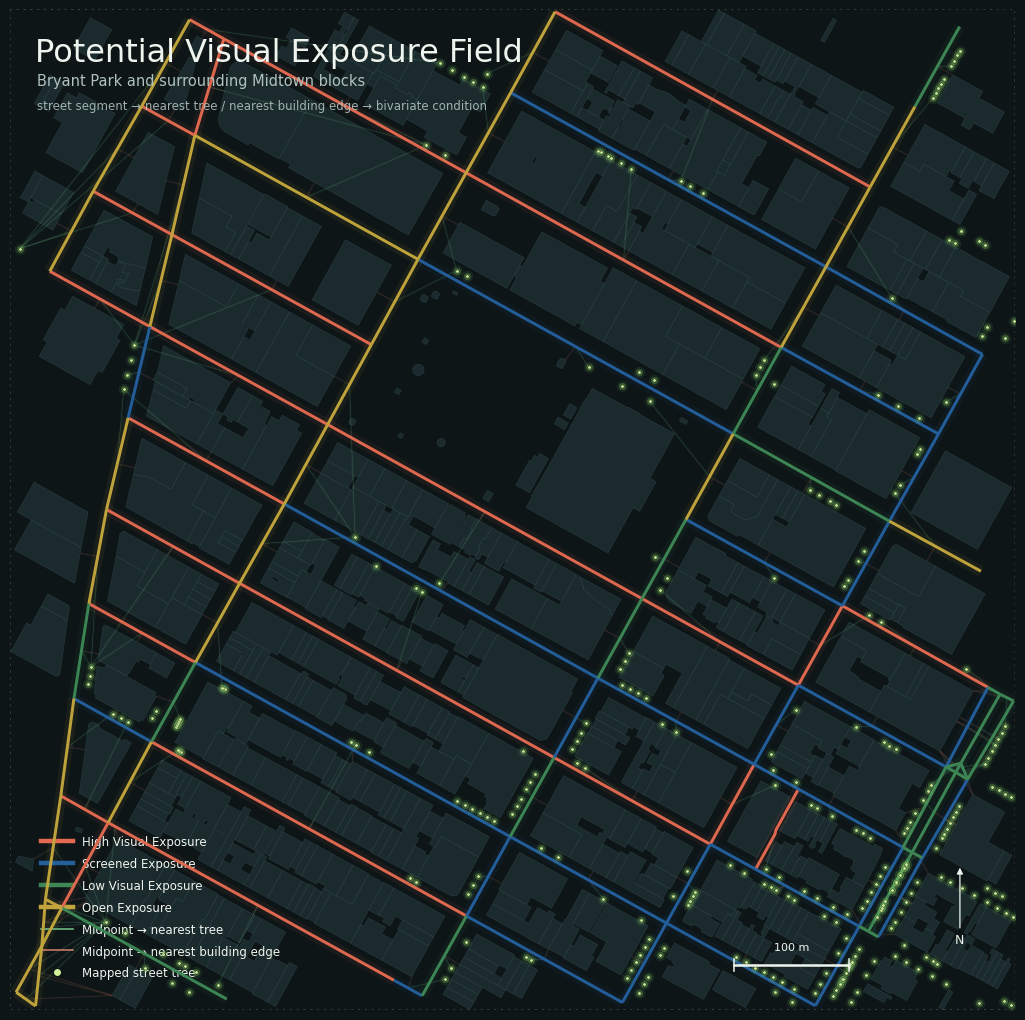

Saved atmospheric presentation map: outputs/potential_visual_exposure_field.png


In [18]:
# Set this to 2 or 3 if the relationship field appears too dense.
RELATION_SAMPLE_STEP = 1

tree_links_display = tree_links.iloc[::RELATION_SAMPLE_STEP].copy()
building_links_display = building_links.iloc[::RELATION_SAMPLE_STEP].copy()

fig, ax = plt.subplots(figsize=(13, 13), facecolor=HERO_BG)
fig.patch.set_facecolor(HERO_BG)
ax.set_facecolor(HERO_BG)

# 1. Dark urban mass.
buildings.plot(
    ax=ax,
    facecolor=HERO_BUILDING_FILL,
    edgecolor=HERO_BUILDING_EDGE,
    linewidth=0.28,
    alpha=0.78,
    zorder=1
)

# 2. Faint street-network skeleton.
streets.plot(
    ax=ax,
    color=HERO_STREET_BASE,
    linewidth=0.8,
    alpha=0.55,
    zorder=2
)

# 3. Relationship fields: transparent glow plus a crisp inner line.
tree_links_display.plot(
    ax=ax,
    color=HERO_TREE_LINK,
    linewidth=2.0,
    alpha=0.035,
    zorder=3
)
tree_links_display.plot(
    ax=ax,
    color=HERO_TREE_LINK,
    linewidth=0.38,
    alpha=0.25,
    zorder=4
)

building_links_display.plot(
    ax=ax,
    color=HERO_BUILDING_LINK,
    linewidth=2.0,
    alpha=0.03,
    zorder=3
)
building_links_display.plot(
    ax=ax,
    color=HERO_BUILDING_LINK,
    linewidth=0.38,
    alpha=0.22,
    zorder=4
)

# 4. Exposure-condition glow.
for condition in category_order:
    subset = street_results[
        street_results["exposure_condition"] == condition
    ]
    subset.plot(
        ax=ax,
        color=EXPOSURE_COLORS[condition],
        linewidth=8.0,
        alpha=0.075,
        zorder=5
    )

# 5. Crisp classified street network.
for condition in category_order:
    subset = street_results[
        street_results["exposure_condition"] == condition
    ]
    subset.plot(
        ax=ax,
        color=EXPOSURE_COLORS[condition],
        linewidth=2.15,
        alpha=0.98,
        zorder=6
    )

# 6. Glowing tree nodes.
trees.plot(
    ax=ax,
    color=HERO_TREE_GLOW,
    markersize=55,
    alpha=0.07,
    zorder=7
)
trees.plot(
    ax=ax,
    color=HERO_TREE_GLOW,
    markersize=18,
    alpha=0.24,
    zorder=8
)
trees.plot(
    ax=ax,
    color=HERO_TREE_CORE,
    edgecolor=HERO_BG,
    linewidth=0.22,
    markersize=5.5,
    alpha=0.95,
    zorder=9
)

# 7. Study-area frame.
study_area_projected.boundary.plot(
    ax=ax,
    color=HERO_MUTED_TEXT,
    linewidth=0.7,
    linestyle=(0, (2, 5)),
    alpha=0.42,
    zorder=10
)

# 8. Title block.
ax.text(
    0.025,
    0.972,
    "Potential Visual Exposure Field",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=23,
    color=HERO_TEXT,
    fontweight="medium",
    zorder=20
)
ax.text(
    0.027,
    0.936,
    "Bryant Park and surrounding Midtown blocks",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    color=HERO_MUTED_TEXT,
    zorder=20
)
ax.text(
    0.027,
    0.910,
    "street segment → nearest tree / nearest building edge → bivariate condition",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.5,
    color=HERO_MUTED_TEXT,
    alpha=0.9,
    zorder=20
)

# 9. Legend.
legend_handles = [
    Line2D(
        [0],
        [0],
        color=EXPOSURE_COLORS[condition],
        linewidth=3.2,
        label=condition
    )
    for condition in category_order
]
legend_handles += [
    Line2D(
        [0],
        [0],
        color=HERO_TREE_LINK,
        linewidth=1.2,
        alpha=0.85,
        label="Midpoint → nearest tree"
    ),
    Line2D(
        [0],
        [0],
        color=HERO_BUILDING_LINK,
        linewidth=1.2,
        alpha=0.85,
        label="Midpoint → nearest building edge"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=HERO_TREE_CORE,
        markeredgecolor=HERO_BG,
        markersize=6,
        label="Mapped street tree"
    )
]

legend = ax.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=False,
    fontsize=8.5,
    labelspacing=0.75,
    handlelength=2.7
)
for text in legend.get_texts():
    text.set_color(HERO_TEXT)

# 10. North arrow and 100 m scale bar.
minx, miny, maxx, maxy = study_area_projected.total_bounds
width = maxx - minx
height = maxy - miny

ax.annotate(
    "N",
    xy=(maxx - 0.055 * width, miny + 0.145 * height),
    xytext=(maxx - 0.055 * width, miny + 0.070 * height),
    ha="center",
    va="center",
    color=HERO_TEXT,
    fontsize=9,
    arrowprops=dict(
        arrowstyle="-|>",
        color=HERO_TEXT,
        linewidth=0.9
    ),
    zorder=20
)

scale_length_ft = 100 / 0.3048006096
scale_x0 = minx + 0.72 * width
scale_y = miny + 0.045 * height

ax.plot(
    [scale_x0, scale_x0 + scale_length_ft],
    [scale_y, scale_y],
    color=HERO_TEXT,
    linewidth=1.8,
    zorder=20
)
ax.plot(
    [scale_x0, scale_x0],
    [scale_y - 0.006 * height, scale_y + 0.006 * height],
    color=HERO_TEXT,
    linewidth=1.1,
    zorder=20
)
ax.plot(
    [scale_x0 + scale_length_ft, scale_x0 + scale_length_ft],
    [scale_y - 0.006 * height, scale_y + 0.006 * height],
    color=HERO_TEXT,
    linewidth=1.1,
    zorder=20
)
ax.text(
    scale_x0 + scale_length_ft / 2,
    scale_y + 0.013 * height,
    "100 m",
    color=HERO_TEXT,
    fontsize=8,
    ha="center",
    va="bottom",
    zorder=20
)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_axis_off()

hero_figure_path = OUTPUT_DIR / "potential_visual_exposure_field.png"
plt.savefig(
    hero_figure_path,
    dpi=320,
    bbox_inches="tight",
    facecolor=HERO_BG,
    pad_inches=0.12
)
plt.show()

print("Saved atmospheric presentation map:", hero_figure_path)


## 15 — Compare the four classes

The table and bar chart summarize how many street segments fall into each condition. Interpret the actual pattern only after running the notebook with the final public datasets.

,exposure_condition,segment_count,percentage
0,High Visual Exposure,26,23.2
1,Screened Exposure,30,26.8
2,Low Visual Exposure,26,23.2
3,Open Exposure,30,26.8


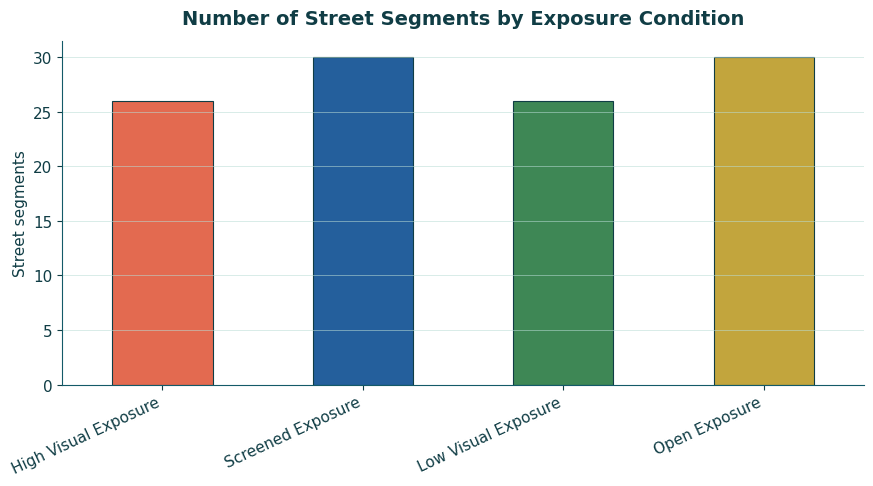

In [19]:
condition_summary = (
    street_results["exposure_condition"]
    .value_counts(sort=False)
    .rename_axis("exposure_condition")
    .reset_index(name="segment_count")
)
condition_summary["percentage"] = (
    condition_summary["segment_count"] / condition_summary["segment_count"].sum() * 100
).round(1)

display(condition_summary)

bar_colors = [EXPOSURE_COLORS[str(c)] for c in condition_summary["exposure_condition"]]
ax = condition_summary.plot(
    x="exposure_condition",
    y="segment_count",
    kind="bar",
    legend=False,
    figsize=(9, 5),
    color=bar_colors,
    edgecolor=INK,
    linewidth=0.8
)
ax.set_title("Number of Street Segments by Exposure Condition", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Street segments")
ax.grid(axis="y", color=LIGHT_CYAN, linewidth=0.7, alpha=0.55)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(DEEP_TEAL)
ax.spines["bottom"].set_color(DEEP_TEAL)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 16 — Inspect extreme examples

Looking at segments with the smallest and largest values helps verify whether the classifications make spatial sense.

In [20]:
display(
    street_results.nsmallest(5, "tree_distance_m")[[
        "segment_id", "tree_distance_m", "building_distance_m", "exposure_condition"
    ]]
)

display(
    street_results.nsmallest(5, "building_distance_m")[[
        "segment_id", "tree_distance_m", "building_distance_m", "exposure_condition"
    ]]
)

,segment_id,tree_distance_m,building_distance_m,exposure_condition
68,SEG_0069,1.985022,21.670226,Low Visual Exposure
17,SEG_0018,4.781115,10.256378,Screened Exposure
57,SEG_0058,4.809523,10.669630,Screened Exposure
69,SEG_0070,5.223991,13.089993,Screened Exposure
23,SEG_0024,5.599968,9.645927,Screened Exposure


,segment_id,tree_distance_m,building_distance_m,exposure_condition
63,SEG_0064,36.161543,2.650177,High Visual Exposure
15,SEG_0016,83.212294,8.522287,High Visual Exposure
91,SEG_0092,68.454011,8.533623,High Visual Exposure
111,SEG_0112,75.980588,8.842179,High Visual Exposure
13,SEG_0014,76.967776,8.863939,High Visual Exposure


## 17 — Findings

The findings below are generated from the final processed dataset rather than inferred from the legend. They summarize class balance, extreme cases, and differences between approximately north–south and east–west street segments. Read them together with the final bivariate map and confirm that the automated descriptions match the visible spatial pattern.

In [21]:
import numpy as np

# Class distribution
class_counts = street_results["exposure_condition"].value_counts()
class_pct = (class_counts / len(street_results) * 100).round(1)
most_common = class_counts.idxmax()
least_common = class_counts.idxmin()

# Extreme measured examples
closest_tree = street_results.loc[street_results["tree_distance_m"].idxmin()]
farthest_tree = street_results.loc[street_results["tree_distance_m"].idxmax()]
closest_building = street_results.loc[street_results["building_distance_m"].idxmin()]
farthest_building = street_results.loc[street_results["building_distance_m"].idxmax()]

# Compare approximate street orientations in the projected CRS.
def segment_orientation(geom):
    if geom is None or geom.is_empty:
        return "Unclassified"
    coords = list(geom.coords)
    if len(coords) < 2:
        return "Unclassified"
    dx = abs(coords[-1][0] - coords[0][0])
    dy = abs(coords[-1][1] - coords[0][1])
    return "North–South / Avenue-like" if dy > dx else "East–West / Cross-street-like"

orientation_results = street_results.copy()
orientation_results["orientation_group"] = orientation_results.geometry.apply(segment_orientation)
orientation_table = pd.crosstab(
    orientation_results["orientation_group"],
    orientation_results["exposure_condition"],
    normalize="index"
).mul(100).round(1)

orientation_dominant = (
    orientation_results.groupby("orientation_group")["exposure_condition"]
    .agg(lambda s: s.value_counts().idxmax())
)

print("DATA-SUPPORTED FINDINGS")
print("—" * 72)
print(
    f"1. {most_common} is the most common condition "
    f"({class_counts[most_common]} segments; {class_pct[most_common]:.1f}%), while "
    f"{least_common} is the least common "
    f"({class_counts[least_common]} segments; {class_pct[least_common]:.1f}%)."
)
print(
    f"2. Tree proximity ranges from {closest_tree['tree_distance_m']:.2f} m "
    f"({closest_tree['segment_id']}) to {farthest_tree['tree_distance_m']:.2f} m "
    f"({farthest_tree['segment_id']}). Building-edge proximity ranges from "
    f"{closest_building['building_distance_m']:.2f} m ({closest_building['segment_id']}) "
    f"to {farthest_building['building_distance_m']:.2f} m "
    f"({farthest_building['segment_id']})."
)
for group, condition in orientation_dominant.items():
    print(f"3. Within {group} segments, the dominant class is {condition}.")
print(
    "4. These patterns represent relative proximity conditions within this study "
    "area; they do not demonstrate actual visibility, surveillance, safety, or comfort."
)

print("\nORIENTATION COMPARISON (% WITHIN EACH ORIENTATION GROUP)")
display(orientation_table)

DATA-SUPPORTED FINDINGS
————————————————————————————————————————————————————————————————————————
1. Screened Exposure is the most common condition (30 segments; 26.8%), while High Visual Exposure is the least common (26 segments; 23.2%).
2. Tree proximity ranges from 1.99 m (SEG_0069) to 204.25 m (SEG_0048). Building-edge proximity ranges from 2.65 m (SEG_0064) to 75.50 m (SEG_0003).
3. Within East–West / Cross-street-like segments, the dominant class is High Visual Exposure.
3. Within North–South / Avenue-like segments, the dominant class is Open Exposure.
4. These patterns represent relative proximity conditions within this study area; they do not demonstrate actual visibility, surveillance, safety, or comfort.

ORIENTATION COMPARISON (% WITHIN EACH ORIENTATION GROUP)


exposure_condition,High Visual Exposure,Screened Exposure,Low Visual Exposure,Open Exposure
orientation_group,,,,
East–West / Cross-street-like,40.4,30.8,21.2,7.7
North–South / Avenue-like,8.3,23.3,25.0,43.3


## 18 — Limitations

The analysis does not include:

- building height or the number and orientation of windows;
- building occupancy or time-dependent activity;
- tree-canopy width, density, or seasonal foliage;
- viewing direction, eye height, or actual lines of sight;
- parked vehicles, street furniture, crowds, or temporary obstructions;
- all park-interior trees, if they are absent from the street-tree dataset.

The method also reduces each street segment to one midpoint. This creates a consistent comparison, but longer segments may contain substantial variation that one point cannot capture. The median-based Near/Far thresholds are relative to this specific study area and should not be interpreted as universal exposure standards.

The final map therefore represents **potential visual-exposure conditions based on proximity**, not actual surveillance, safety, comfort, or visibility.

## 19 — Reflection and Future Development

The current model simplifies each street segment into one midpoint and reduces buildings and trees to nearest-distance measurements. This provides a reproducible way to compare the entire study area, but physical proximity is not the same as visual obstruction or observation. The bivariate categories are also relative classifications: changing the study boundary or the median thresholds may change the final pattern.

In future semesters, I would replace the single midpoint with multiple sampling points along each street segment and compare results across different spatial resolutions. Building height, façade orientation, window density, tree-canopy dimensions, street width, eye height, and viewing direction could be incorporated into a three-dimensional visibility or ray-casting model. The computational results could then be compared with seating locations, pedestrian observations, or perceived-comfort surveys. Finally, the exported GeoJSON could support an interactive web map in which users inspect each contributing variable and adjust the classification thresholds.

### Proposed Development Path

1. **Increase spatial resolution:** sample each segment at regular intervals rather than at one midpoint.
2. **Add three-dimensional urban form:** integrate building height, façade orientation, windows, and tree canopy.
3. **Validate the proxy:** compare the computed conditions with field observations and human experience.
4. **Build an interactive interface:** allow users to inspect variables, thresholds, and alternative classifications.

## 20 — Export the processed result

The final GeoJSON can be used later in MapLibre, Leaflet, or another web-mapping interface.

In [22]:
export_columns = [
    "segment_id",
    "tree_distance_m",
    "building_distance_m",
    "tree_class",
    "building_class",
    "exposure_condition",
    "geometry"
]

export_gdf = street_results[export_columns].copy()
export_gdf["exposure_condition"] = export_gdf["exposure_condition"].astype(str)
export_gdf = export_gdf.to_crs("EPSG:4326")

geojson_path = OUTPUT_DIR / "bryant_park_visual_exposure.geojson"
csv_path = OUTPUT_DIR / "bryant_park_visual_exposure.csv"

export_gdf.to_file(geojson_path, driver="GeoJSON")
export_gdf.drop(columns="geometry").to_csv(csv_path, index=False)

print("Saved:", geojson_path)
print("Saved:", csv_path)

Saved: outputs/bryant_park_visual_exposure.geojson
Saved: outputs/bryant_park_visual_exposure.csv


## Final output

After successful execution, the project produces:

- a street-segment dataset with `tree_distance_m`;
- a street-segment dataset with `building_distance_m`;
- relative Near/Far classes for both variables;
- four combined potential visual-exposure conditions;
- a dark atmospheric synthesis map with explicit tree and building relationship lines;
- a 320 dpi presentation image saved as `outputs/potential_visual_exposure_field.png`;
- a final bivariate street map;
- an exported GeoJSON and CSV for future web mapping.